In [1]:
import os
os.makedirs('sql', exist_ok=True)
print('✅ sql 폴더 생성 완료')

✅ sql 폴더 생성 완료


In [2]:
%%writefile sql/01_total_cost.sql
-- 날짜별 목적지별 총 여행 비용 계산 (항공 + 숙박 × 여행일수 + 교통)

SELECT
    f.departure_date,
    f.destination,
    f.airline_name,
    f.airline_type,
    f.price                                               AS flight_price,
    h.avg_price_per_night                                 AS hotel_price_per_night,
    t.price                                               AS transport_price,
    t.transport_type,
    f.is_weekend,
    f.is_peak_season,
    f.month,
    f.price + (h.avg_price_per_night * 2) + t.price      AS total_cost_2nights,
    f.price + (h.avg_price_per_night * 3) + t.price      AS total_cost_3nights,
    f.price + (h.avg_price_per_night * 4) + t.price      AS total_cost_4nights

FROM `flight-analysis-2026.flight_analysis.flights` f
LEFT JOIN `flight-analysis-2026.flight_analysis.hotels` h
    ON f.departure_date = h.date
    AND f.destination   = h.destination
LEFT JOIN `flight-analysis-2026.flight_analysis.transportation` t
    ON f.destination = t.destination
WHERE t.airport_to_city = TRUE

Writing sql/01_total_cost.sql


In [3]:
%%writefile sql/02_best_dates_ranking.sql
-- 총 비용 기준 최저 날짜 조합 랭킹 (3박 4일 기준)

WITH total_cost AS (
    SELECT
        f.departure_date,
        f.destination,
        f.airline_name,
        f.airline_type,
        f.price                                               AS flight_price,
        h.avg_price_per_night                                 AS hotel_price_per_night,
        MIN(t.price)                                          AS min_transport_price,
        f.price + (h.avg_price_per_night * 3) + MIN(t.price) AS total_cost_3nights,
        f.is_weekend,
        f.is_peak_season,
        f.month
    FROM `flight-analysis-2026.flight_analysis.flights` f
    LEFT JOIN `flight-analysis-2026.flight_analysis.hotels` h
        ON f.departure_date = h.date
        AND f.destination   = h.destination
    LEFT JOIN `flight-analysis-2026.flight_analysis.transportation` t
        ON f.destination = t.destination
    WHERE t.airport_to_city = TRUE
    GROUP BY
        f.departure_date, f.destination, f.airline_name,
        f.airline_type, f.price, h.avg_price_per_night,
        f.is_weekend, f.is_peak_season, f.month
)
SELECT
    departure_date,
    destination,
    airline_name,
    airline_type,
    flight_price,
    hotel_price_per_night,
    min_transport_price,
    total_cost_3nights,
    is_weekend,
    is_peak_season,
    month,
    RANK() OVER (
        PARTITION BY destination
        ORDER BY total_cost_3nights ASC
    ) AS cost_rank
FROM total_cost
ORDER BY destination, cost_rank

Writing sql/02_best_dates_ranking.sql


In [4]:
%%writefile sql/03_weekend_filter.sql
-- 주말 포함 vs 평일 여행 비용 비교

WITH total_cost AS (
    SELECT
        f.departure_date,
        f.destination,
        f.airline_name,
        f.airline_type,
        f.price + (h.avg_price_per_night * 3) + MIN(t.price) AS total_cost_3nights,
        f.is_weekend,
        f.is_peak_season
    FROM `flight-analysis-2026.flight_analysis.flights` f
    LEFT JOIN `flight-analysis-2026.flight_analysis.hotels` h
        ON f.departure_date = h.date
        AND f.destination   = h.destination
    LEFT JOIN `flight-analysis-2026.flight_analysis.transportation` t
        ON f.destination = t.destination
    WHERE t.airport_to_city = TRUE
    GROUP BY
        f.departure_date, f.destination, f.airline_name,
        f.airline_type, f.price, h.avg_price_per_night,
        f.is_weekend, f.is_peak_season
)
SELECT
    destination,
    is_weekend,
    ROUND(AVG(total_cost_3nights), 0) AS avg_total_cost,
    ROUND(MIN(total_cost_3nights), 0) AS min_total_cost,
    ROUND(MAX(total_cost_3nights), 0) AS max_total_cost,
    COUNT(*)                          AS date_count
FROM total_cost
GROUP BY destination, is_weekend
ORDER BY destination, is_weekend

Writing sql/03_weekend_filter.sql


In [5]:
%%writefile sql/04_peak_vs_offpeak.sql
-- 성수기 vs 비수기 목적지별 평균 총 비용 비교

WITH total_cost AS (
    SELECT
        f.destination,
        f.airline_type,
        f.price + (h.avg_price_per_night * 3) + MIN(t.price) AS total_cost_3nights,
        f.is_peak_season,
        f.month
    FROM `flight-analysis-2026.flight_analysis.flights` f
    LEFT JOIN `flight-analysis-2026.flight_analysis.hotels` h
        ON f.departure_date = h.date
        AND f.destination   = h.destination
    LEFT JOIN `flight-analysis-2026.flight_analysis.transportation` t
        ON f.destination = t.destination
    WHERE t.airport_to_city = TRUE
    GROUP BY
        f.departure_date, f.destination, f.airline_type,
        f.price, h.avg_price_per_night,
        f.is_peak_season, f.month
)
SELECT
    destination,
    is_peak_season,
    ROUND(AVG(total_cost_3nights), 0) AS avg_total_cost,
    ROUND(MIN(total_cost_3nights), 0) AS min_total_cost,
    ROUND(MAX(total_cost_3nights), 0) AS max_total_cost,
    COUNT(*)                          AS date_count
FROM total_cost
GROUP BY destination, is_peak_season
ORDER BY destination, is_peak_season

Writing sql/04_peak_vs_offpeak.sql


In [6]:
%%writefile sql/05_fsc_vs_lcc.sql
-- FSC vs LCC 노선별 가격 비교 및 절감액 분석

SELECT
    destination,
    airline_type,
    ROUND(AVG(price), 0)         AS avg_flight_price,
    ROUND(MIN(price), 0)         AS min_flight_price,
    ROUND(MAX(price), 0)         AS max_flight_price,
    COUNT(DISTINCT airline_name) AS airline_count
FROM `flight-analysis-2026.flight_analysis.flights`
GROUP BY destination, airline_type
ORDER BY destination, airline_type

Writing sql/05_fsc_vs_lcc.sql


# analystic

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

PROJECT_ID = 'flight-analysis-2026'
DATASET_ID = 'flight_analysis'
client     = bigquery.Client(project=PROJECT_ID)

plt.rcParams['font.family']       = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 설정 완료')

✅ 설정 완료


In [2]:
def run_sql(filename):
    with open(f'sql/{filename}', 'r', encoding='utf-8') as f:
        query = f.read()
    return client.query(query).to_dataframe()

print('✅ SQL 실행 함수 준비 완료')

✅ SQL 실행 함수 준비 완료


In [4]:
print('🔄 SQL 쿼리 실행 중...')

df_total_cost   = run_sql('01_total_cost.sql')
print('  ✅ 01_total_cost 완료:', len(df_total_cost), '행')

df_ranking      = run_sql('02_best_dates_ranking.sql')
print('  ✅ 02_best_dates_ranking 완료:', len(df_ranking), '행')

df_weekend      = run_sql('03_weekend_filter.sql')
print('  ✅ 03_weekend_filter 완료:', len(df_weekend), '행')

df_peak         = run_sql('04_peak_vs_offpeak.sql')
print('  ✅ 04_peak_vs_offpeak 완료:', len(df_peak), '행')

df_fsc_lcc      = run_sql('05_fsc_vs_lcc.sql')
print('  ✅ 05_fsc_vs_lcc 완료:', len(df_fsc_lcc), '행')

print('\n🎉 모든 쿼리 실행 완료!')

🔄 SQL 쿼리 실행 중...
  ✅ 01_total_cost 완료: 58400 행
  ✅ 02_best_dates_ranking 완료: 23360 행
  ✅ 03_weekend_filter 완료: 50 행
  ✅ 04_peak_vs_offpeak 완료: 50 행
  ✅ 05_fsc_vs_lcc 완료: 32 행

🎉 모든 쿼리 실행 완료!


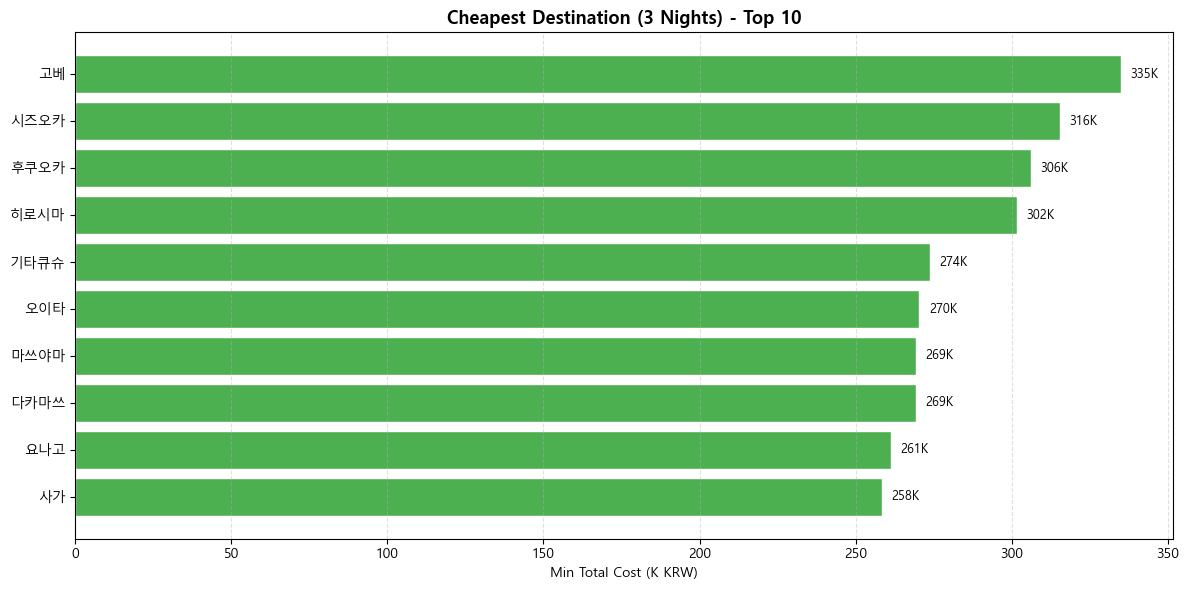

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# 목적지별 최저 총비용 (3박 4일)
best = (df_ranking.groupby('destination')['total_cost_3nights']
        .min()
        .sort_values()
        .head(10))

colors = ['#4CAF50' if v < 500000 else '#5C7CFA' for v in best.values]
bars = ax.barh(best.index, best.values / 1000, color=colors, edgecolor='white')

for bar, val in zip(bars, best.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'{val/1000:,.0f}K', va='center', fontsize=9)

ax.set_title('Cheapest Destination (3 Nights) - Top 10', fontweight='bold', fontsize=13)
ax.set_xlabel('Min Total Cost (K KRW)')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('data/viz_01_cheapest_destination.png', dpi=150, bbox_inches='tight')
plt.show()

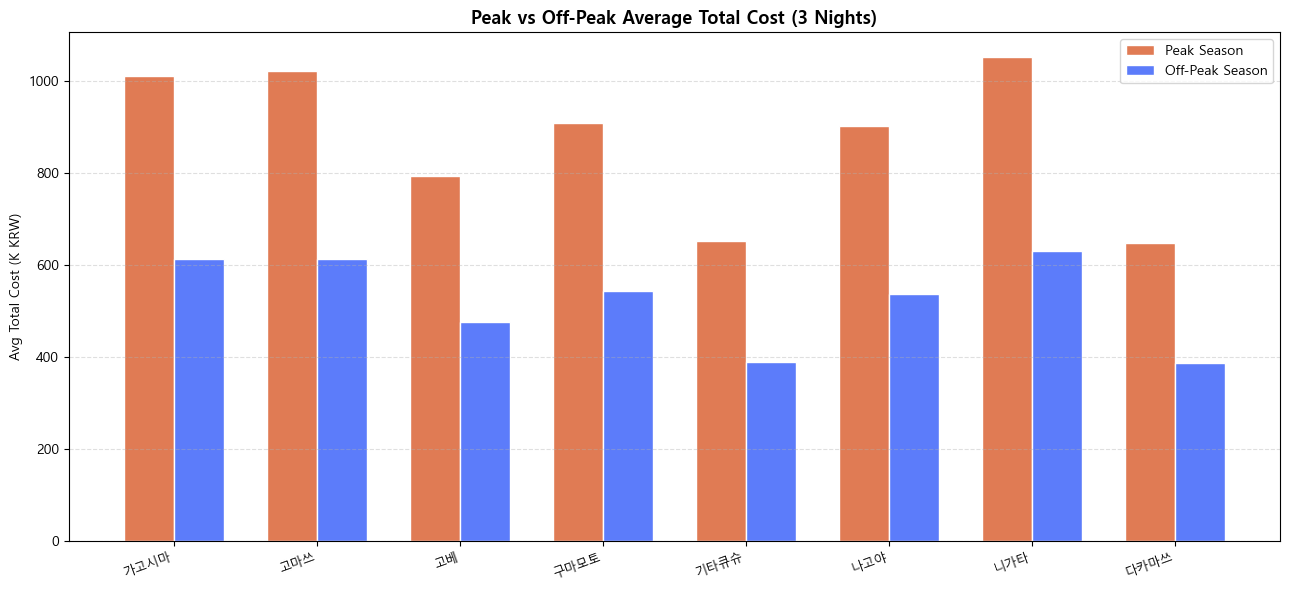

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

destinations = ['Fukuoka', '후쿠오카', 'Osaka', '오사카(간사이)', '도쿄(나리타)', '삿포로', '오키나와']
df_peak_filter = df_peak[df_peak['destination'].isin(
    df_peak['destination'].unique()[:8]
)]

peak    = df_peak_filter[df_peak_filter['is_peak_season'] == True].set_index('destination')['avg_total_cost']
offpeak = df_peak_filter[df_peak_filter['is_peak_season'] == False].set_index('destination')['avg_total_cost']
common  = peak.index.intersection(offpeak.index)

x      = range(len(common))
width  = 0.35

ax.bar([i - width/2 for i in x], peak[common] / 1000,
       width=width, label='Peak Season', color='#E07B54', edgecolor='white')
ax.bar([i + width/2 for i in x], offpeak[common] / 1000,
       width=width, label='Off-Peak Season', color='#5C7CFA', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(common, rotation=20, ha='right', fontsize=9)
ax.set_title('Peak vs Off-Peak Average Total Cost (3 Nights)', fontweight='bold', fontsize=13)
ax.set_ylabel('Avg Total Cost (K KRW)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('data/viz_02_peak_vs_offpeak.png', dpi=150, bbox_inches='tight')
plt.show()

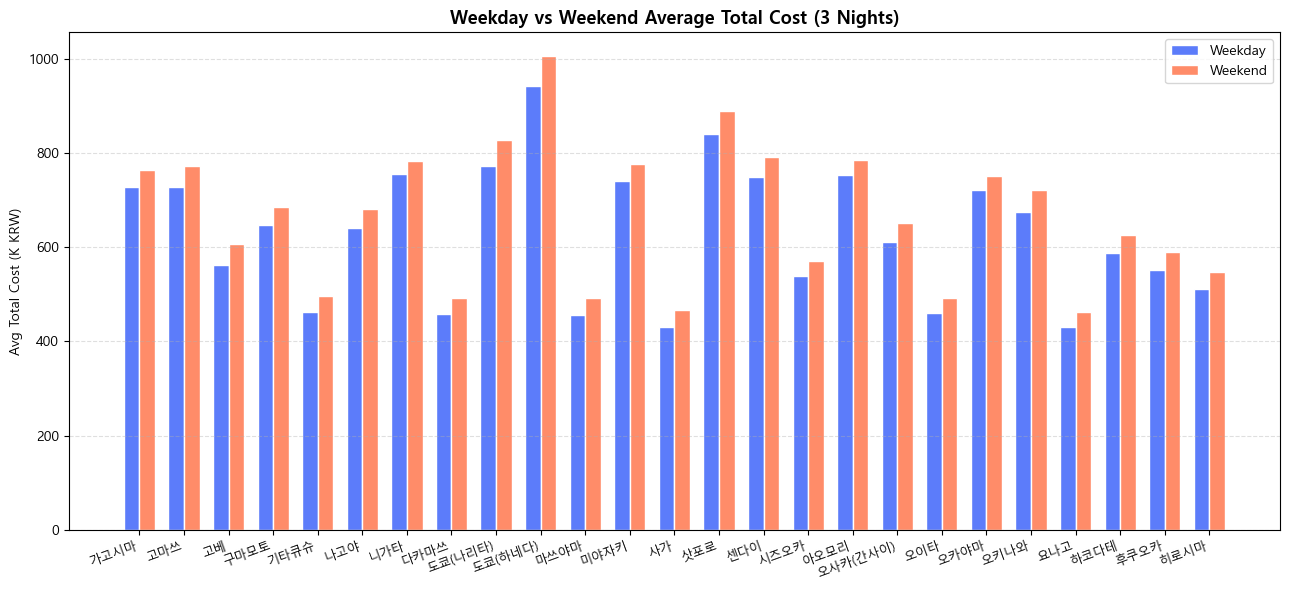

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

weekend_true  = df_weekend[df_weekend['is_weekend'] == True].set_index('destination')['avg_total_cost']
weekend_false = df_weekend[df_weekend['is_weekend'] == False].set_index('destination')['avg_total_cost']
common        = weekend_true.index.intersection(weekend_false.index)

x     = range(len(common))
width = 0.35

ax.bar([i - width/2 for i in x], weekend_false[common] / 1000,
       width=width, label='Weekday', color='#5C7CFA', edgecolor='white')
ax.bar([i + width/2 for i in x], weekend_true[common] / 1000,
       width=width, label='Weekend', color='#FF8C69', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(common, rotation=20, ha='right', fontsize=9)
ax.set_title('Weekday vs Weekend Average Total Cost (3 Nights)', fontweight='bold', fontsize=13)
ax.set_ylabel('Avg Total Cost (K KRW)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('data/viz_03_weekend_vs_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

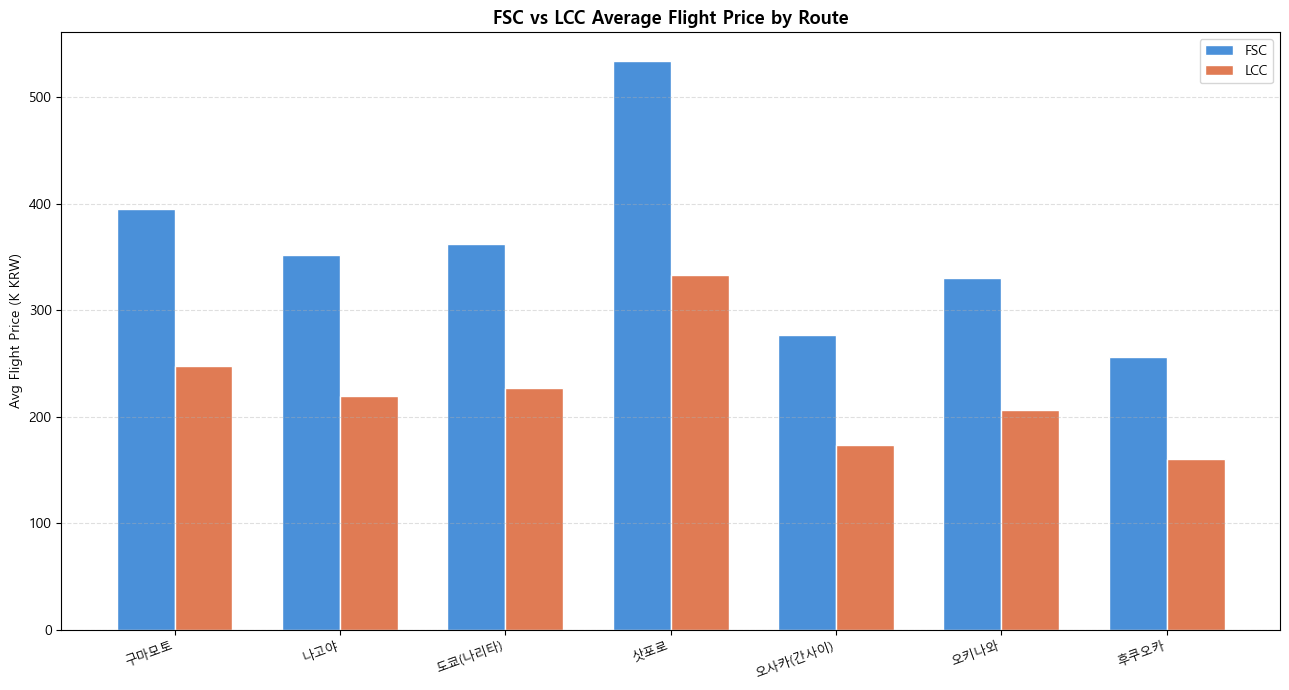

In [8]:
fig, ax = plt.subplots(figsize=(13, 7))

fsc = df_fsc_lcc[df_fsc_lcc['airline_type'] == 'FSC'].set_index('destination')['avg_flight_price']
lcc = df_fsc_lcc[df_fsc_lcc['airline_type'] == 'LCC'].set_index('destination')['avg_flight_price']
common = fsc.index.intersection(lcc.index)

x     = range(len(common))
width = 0.35

ax.bar([i - width/2 for i in x], fsc[common] / 1000,
       width=width, label='FSC', color='#4A90D9', edgecolor='white')
ax.bar([i + width/2 for i in x], lcc[common] / 1000,
       width=width, label='LCC', color='#E07B54', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(common, rotation=20, ha='right', fontsize=9)
ax.set_title('FSC vs LCC Average Flight Price by Route', fontweight='bold', fontsize=13)
ax.set_ylabel('Avg Flight Price (K KRW)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('data/viz_04_fsc_vs_lcc.png', dpi=150, bbox_inches='tight')
plt.show()


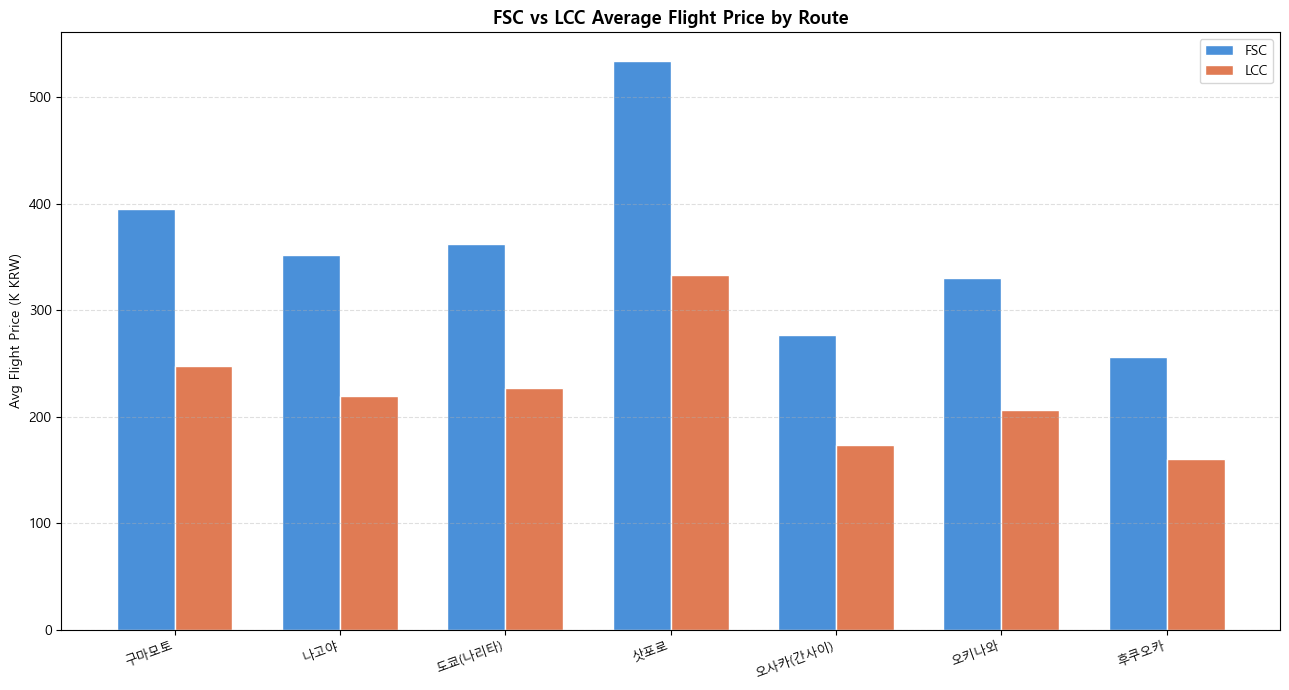

In [9]:
fig, ax = plt.subplots(figsize=(13, 7))

fsc = df_fsc_lcc[df_fsc_lcc['airline_type'] == 'FSC'].set_index('destination')['avg_flight_price']
lcc = df_fsc_lcc[df_fsc_lcc['airline_type'] == 'LCC'].set_index('destination')['avg_flight_price']
common = fsc.index.intersection(lcc.index)

x     = range(len(common))
width = 0.35

ax.bar([i - width/2 for i in x], fsc[common] / 1000,
       width=width, label='FSC', color='#4A90D9', edgecolor='white')
ax.bar([i + width/2 for i in x], lcc[common] / 1000,
       width=width, label='LCC', color='#E07B54', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(common, rotation=20, ha='right', fontsize=9)
ax.set_title('FSC vs LCC Average Flight Price by Route', fontweight='bold', fontsize=13)
ax.set_ylabel('Avg Flight Price (K KRW)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('data/viz_04_fsc_vs_lcc.png', dpi=150, bbox_inches='tight')
plt.show()